# Exploratory Feature Analysis (EFA)
## Home Credit Default Risk

### 1. Purpose of This Notebook

This notebook focuses on the **exploratory analysis of engineered features** contained in the consolidated feature store developed for the Home Credit Default Risk problem.

While the previous notebook evaluated the **quality of the feature store** (e.g., missing values, duplicate records, feature cardinality, data types, and consistency checks), the purpose of this notebook is to understand the **behavior and predictive characteristics** of the engineered features.

An initial set of **ten features** was selected based on domain intuition and prior knowledge of credit risk. These features were engineered from all available datasets (`bureau`, `bureau_balance`, `previous_application`, `POS_CASH_balance`, `installments_payments`, and `credit_card_balance`) and represent different aspects of a customer's financial history, including debt exposure, payment behavior, credit utilization, and delinquency patterns.

For each feature, the analysis aims to evaluate:

- Its relationship with the target (`TARGET`);
- Whether the relationship is monotonic or exhibits meaningful trends;
- The statistical reliability of the observed patterns;
- The business interpretation behind the feature and its relationship with default risk.

This notebook serves as an exploratory step to better understand the predictive information captured by the engineered features before proceeding to model development.

# 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import sys
from pathlib import Path

project_root = Path("/home/priscila/Desktop/Estudos/home_credit_default_risk_mle")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Feature Store — Exploratory Data Analysis

In [31]:
feature_store = pd.read_parquet("../data/feature_store_train.parquet")

print(f"Rows: {feature_store.shape[0]:,}")
print(f"Columns: {feature_store.shape[1]:,}")
feature_store.head()

Rows: 307,511
Columns: 83


,SK_ID_CURR,TARGET,BUREAU_TOTAL_LOAN_COUNT,BUREAU_ACTIVE_LOAN_COUNT,BUREAU_CLOSED_LOAN_COUNT,BUREAU_ACTIVE_LOAN_RATIO,BUREAU_DAYS_CREDIT_MOST_RECENT,BUREAU_DAYS_CREDIT_OLDEST,BUREAU_DAYS_CREDIT_SPAN,BUREAU_OVERDUE_LOAN_RATIO,...,PREV_AMT_APPLICATION_MEAN,PREV_AMT_ANNUITY_MEAN,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_CREDIT_TO_APPLICATION_RATIO_MEAN,PREV_CREDIT_MINUS_APPLICATION_MEAN,PREV_APPROVAL_RATIO,PREV_REFUSED_RATIO,PREV_HAS_REFUSED_FLAG,PREV_DAYS_DECISION_SPAN
0,100002,1,8.0,2.0,6.0,0.25,-103.0,-1437.0,1334.0,0.375,...,179055.00,9251.775391,24.000000,24.0,1.000000,0.000000,1.000000,0.000000,0.0,0.0
1,100003,0,4.0,1.0,3.0,0.25,-606.0,-2586.0,1980.0,0.000,...,435436.50,56553.988281,10.000000,12.0,1.057617,48754.500000,1.000000,0.000000,0.0,1595.0
2,100004,0,2.0,0.0,2.0,0.00,-408.0,-1326.0,918.0,0.000,...,24282.00,5357.250000,4.000000,4.0,0.828125,-4176.000000,1.000000,0.000000,0.0,0.0
3,100006,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,272203.25,23651.173828,23.000000,48.0,0.675293,19492.240234,0.555664,0.111084,1.0,436.0
4,100007,0,1.0,0.0,1.0,0.00,-1149.0,-1149.0,0.0,0.000,...,150530.25,12278.804688,20.671875,48.0,1.045898,16108.500000,1.000000,0.000000,0.0,1983.0


# 1. Payment Behavior

---
**Feature 1.1: INST_LATE_RATIO**

Definition:
Proportion of installments paid late.

Calculated as:
Number of installments with DPD > 0 divided by total number of installments.

Interpretation:
Measures how frequently the client pays late.

Signal captured:

Behavioral consistency
Chronic delinquency tendency

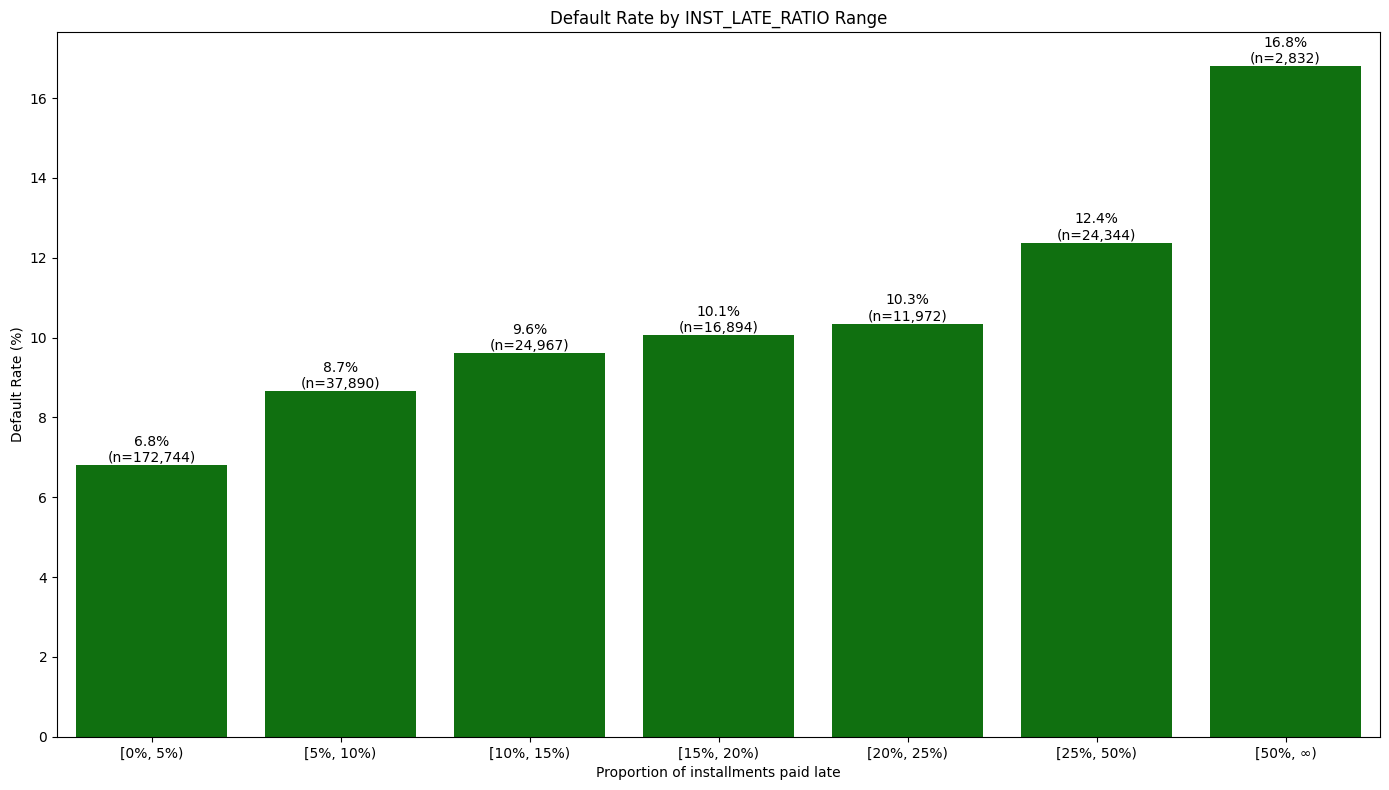

In [70]:
bins = [0, 5, 10, 15, 20, 25, 50, np.inf]

labels = [
    "[0%, 5%)",
    "[5%, 10%)",
    "[10%, 15%)",
    "[15%, 20%)",
    "[20%, 25%)",
    "[25%, 50%)",
    "[50%, ∞)"
]

df_plot = feature_store.copy()

df_plot['INST_LATE_RATIO'] = (
    round(df_plot['INST_LATE_RATIO']
    .astype('float32')*100,0)
)

df_plot['LOAN_COUNT_BIN'] = pd.cut(
    df_plot['INST_LATE_RATIO'],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby('LOAN_COUNT_BIN', observed=False)
    .agg(
        default_rate=('TARGET', 'mean'),
        total_clients=('TARGET', 'count'),
        total_defaults=('TARGET', 'sum')
    )
    .reset_index()
)

default_rate['default_rate'] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x='LOAN_COUNT_BIN',
    y='default_rate',
    color='green'
)

plt.title('Default Rate by INST_LATE_RATIO Range')
plt.xlabel('Proportion of installments paid late')
plt.ylabel('Default Rate (%)')

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f'{height:.1f}%\n(n={row.total_clients:,})',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

**INST_LATE_RATIO** demonstrates a clear positive relationship with default risk. Customers who pay a larger proportion of their installments late exhibit progressively higher default rates, increasing from 6.8% for clients with fewer than 5% of late installments to 16.8% for those with more than half of their installments paid late. From a business perspective, the feature captures the consistency of a customer's payment behavior and serves as an indicator of chronic defaul behavior rather than isolated late-payment events, making it a highly interpretable measure of credit risk.

---
**Feature 1.2: INST_DPD_30_RATIO**

Definition:
Proportion of installments with DPD greater than 30 days.

Interpretation:
Measures frequency of severe DPD.

Signal captured:

- Material credit deterioration
- Risk of transition into default

In [74]:
df_plot["INST_DPD_30_RATIO"].quantile(
    [.50,.75,.90,.95,.99,.995,.999]
)

0.500     0.0
0.750     0.0
0.900     0.0
0.950     2.0
0.990     8.0
0.995    11.0
0.999    20.0
Name: INST_DPD_30_RATIO, dtype: float32

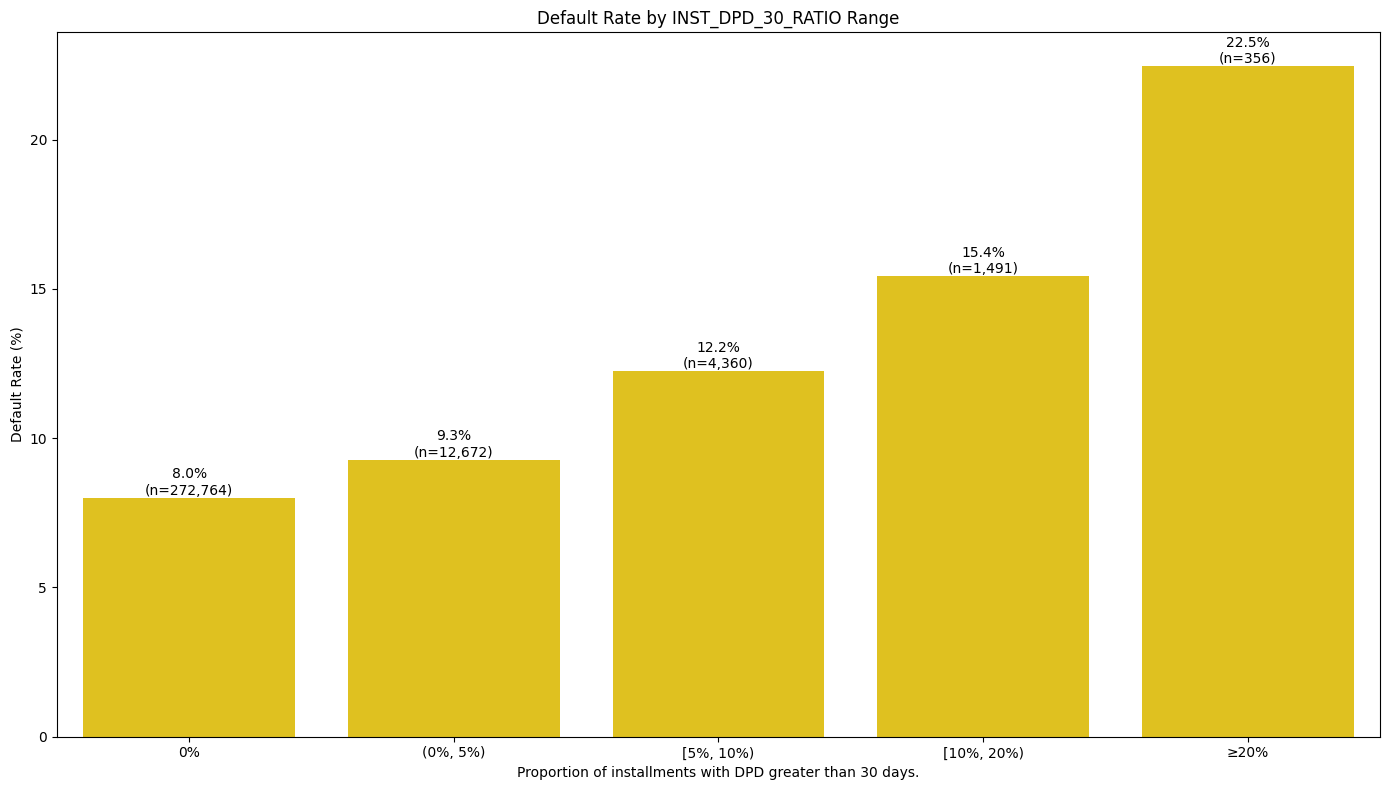

In [78]:
bins = [-0.1, 0.1, 5, 10, 20, np.inf]

labels = [
    "0%",
    "(0%, 5%)",
    "[5%, 10%)",
    "[10%, 20%)",
    "≥20%"
]

df_plot = feature_store[["TARGET", "INST_DPD_30_RATIO"]].copy()

df_plot['INST_DPD_30_RATIO'] = (
    round(df_plot['INST_DPD_30_RATIO']
    .astype('float32')*100,0)
)

df_plot['LOAN_COUNT_BIN'] = pd.cut(
    df_plot['INST_DPD_30_RATIO'],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot
    .groupby('LOAN_COUNT_BIN', observed=False)
    .agg(
        default_rate=('TARGET', 'mean'),
        total_clients=('TARGET', 'count'),
        total_defaults=('TARGET', 'sum')
    )
    .reset_index()
)

default_rate['default_rate'] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x='LOAN_COUNT_BIN',
    y='default_rate',
    color='gold'
)

plt.title('Default Rate by INST_DPD_30_RATIO Range')
plt.xlabel('Proportion of installments with DPD greater than 30 days.')
plt.ylabel('Default Rate (%)')

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f'{height:.1f}%\n(n={row.total_clients:,})',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [83]:
print(f"{round((df_plot["INST_DPD_30_RATIO"] == 0).mean()*100,2)}% of customers never experienced a 30+ day overdue installment")

88.7% of customers never experienced a 30+ day overdue installment


**INST_DPD_30_RATIO** demonstrates a strong positive relationship with default risk. Customers with a higher proportion of installments paid more than 30 days late exhibit progressively higher default rates, indicating that repeated severe payment delays are closely associated with future default. Notably, **88.7%** of customers never experienced a 30+ day overdue installment (INST_DPD_30_RATIO = 0%), highlighting that severe payment delays are relatively rare in the portfolio. As the proportion of severely overdue installments increases, default rates rise consistently, reinforcing the feature's ability to capture persistent late payment behavior. The highest ratio groups should be interpreted with some caution due to the smaller number of observations, but the overall trend remains clear.

# 2. Credit Exposure

---
**Feature 2.1: BUREAU_ACTIVE_LOAN_COUNT**

Definition:
Proportion of active loans relative to total loans.

Formula:
ACTIVE_LOAN_RATIO = Active Loans / (Active Loans + Closed Loans)

Interpretation:
Represents how much of the customer’s external credit history is still generating financial obligations.

Risk intuition:

Close to 1 → highly leveraged

Close to 0 → mostly closed obligations

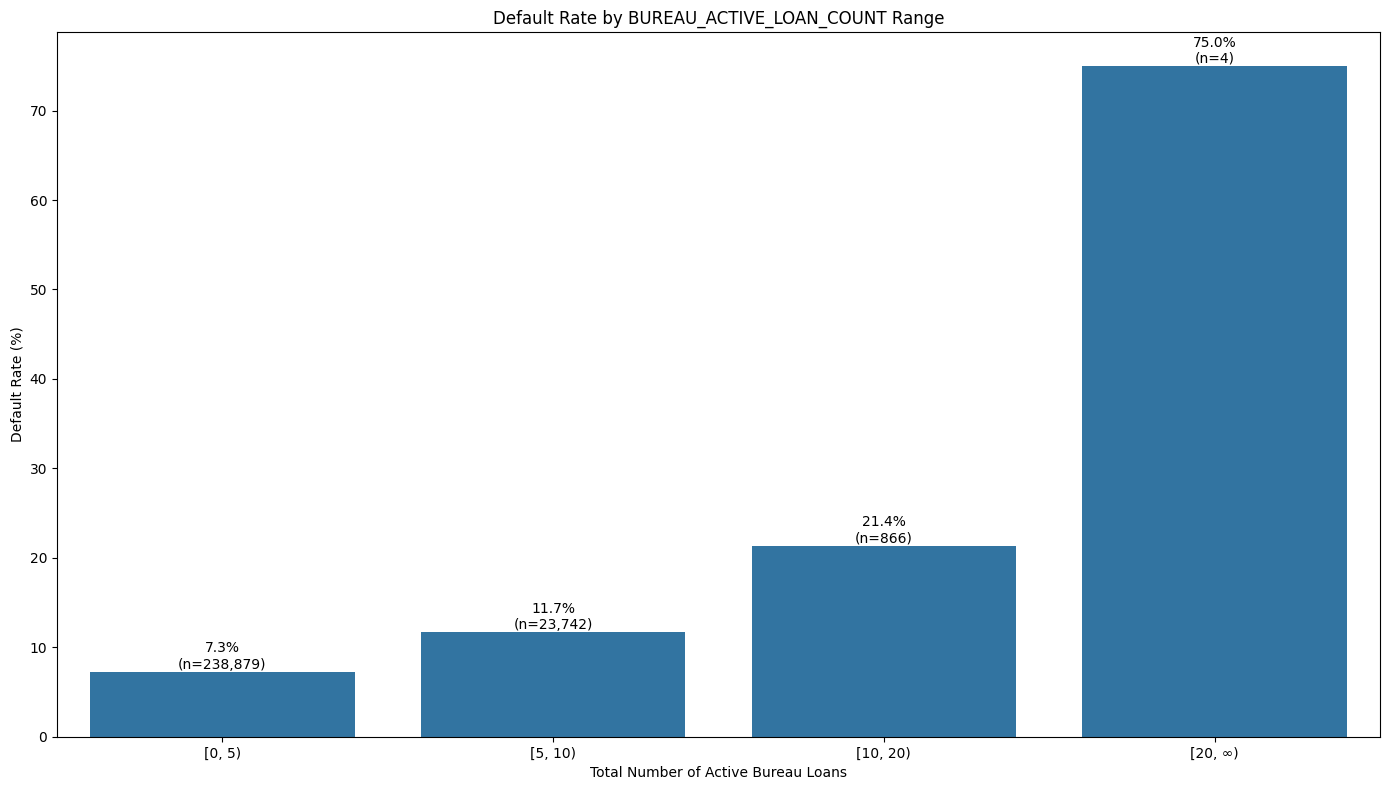

In [69]:
bins = [0, 5, 10, 20, np.inf]

labels = [
    "[0, 5)",
    "[5, 10)",
    "[10, 20)",
    "[20, ∞)"
]

df_plot_3 = feature_store[["TARGET", "BUREAU_ACTIVE_LOAN_COUNT"]].copy()

df_plot_3["BUREAU_ACTIVE_LOAN_COUNT"] = (
    df_plot_3["BUREAU_ACTIVE_LOAN_COUNT"]
    .astype("float32")
)

df_plot_3["LOAN_COUNT_BIN"] = pd.cut(
    df_plot_3["BUREAU_ACTIVE_LOAN_COUNT"],
    bins=bins,
    labels=labels,
    right=False
)

default_rate = (
    df_plot_3
    .groupby("LOAN_COUNT_BIN", observed=False)
    .agg(
        default_rate=("TARGET", "mean"),
        total_clients=("TARGET", "count"),
        total_defaults=("TARGET", "sum")
    )
    .reset_index()
)

default_rate["default_rate"] *= 100

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=default_rate,
    x="LOAN_COUNT_BIN",
    y="default_rate"
)

plt.title("Default Rate by BUREAU_ACTIVE_LOAN_COUNT Range")
plt.xlabel("Total Number of Active Bureau Loans")
plt.ylabel("Default Rate (%)")

for p, row in zip(ax.patches, default_rate.itertuples()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.1f}%\n(n={row.total_clients:,})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

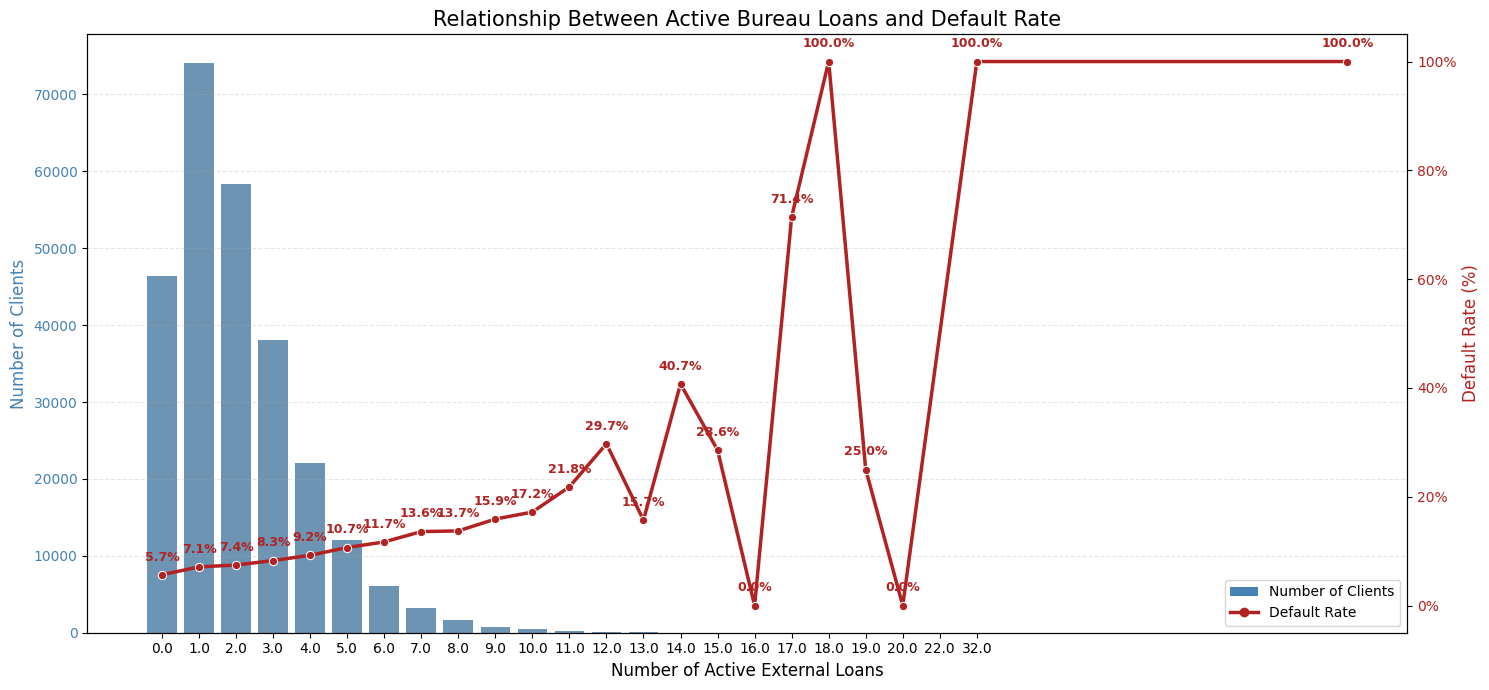

In [ ]:
summary = (
    df_plot_3
    .groupby("BUREAU_ACTIVE_LOAN_COUNT")
    .agg(
        default_rate=("TARGET", "mean"),
        clients=("TARGET", "count")
    )
    .reset_index()
)

summary["default_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(15, 7))

# Bar plot: Number of clients
bars = sns.barplot(
    data=summary,
    x="BUREAU_ACTIVE_LOAN_COUNT",
    y="clients",
    color="steelblue",
    alpha=0.85,
    ax=ax1
)

ax1.set_xlabel("Number of Active External Loans", fontsize=12)
ax1.set_ylabel("Number of Clients", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Line plot: Default rate
ax2 = ax1.twinx()

line = sns.lineplot(
    data=summary,
    x="BUREAU_ACTIVE_LOAN_COUNT",
    y="default_rate",
    marker="o",
    linewidth=2.5,
    color="firebrick",
    ax=ax2
)


for x, y in zip(summary["BUREAU_ACTIVE_LOAN_COUNT"], summary["default_rate"]):
    ax2.annotate(
        f"{y:.1f}%",
        xy=(x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="firebrick",
        fontweight="bold"
    )


ax2.set_ylabel("Default Rate (%)", fontsize=12, color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax2.yaxis.set_major_formatter(PercentFormatter())

plt.title(
    "Relationship Between Active Bureau Loans and Default Rate",
    fontsize=15,
)

plt.xticks(rotation=45)

ax1.grid(axis="y", linestyle="--", alpha=0.3)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor="steelblue", label="Number of Clients"),
    Line2D([0], [0], color="firebrick", marker="o",
           linewidth=2.5, label="Default Rate")
]

ax1.legend(
    handles=legend_elements,
    loc="lower right"
)

plt.tight_layout()
plt.show()

**BUREAU_ACTIVE_LOAN_COUNT** appears to be a strong predictor of default. The default rate increases consistently from 7.3% to 21.4% as the number of active external loans rises from 0-4 to 10-19, suggesting a positive relationship between current external debt exposure and credit risk. The final bin (20+) also exhibits a high observed default rate (75%), although its interpretation is limited by the extremely small sample size (n=4).

Although default rates become substantially higher beyond 12 active loans, these observations should be interpreted with caution due to the extremely small sample size. In fact, 99.9% of customers have 11 or fewer active loans, making the higher observed default rates increasingly volatile and less representative of the overall population.